# Handwritten Character OT Solver Benchmark

We benchmark Linear Programming (LP), PDHG, Sinkhorn, and Back-and-Forth (BFM) solvers on handwritten digits/characters from the `eng_char_and_digits_mann` dataset. Each image is converted into a normalized 2D density on a centered [0,1]^2 grid so every solver sees the same spatial discretization. To keep the Back-and-Forth solver happy we keep the marginals as full `GridMeasure`s, while the other solvers receive point clouds (including zero-weight bins) so their cost matrices span the complete grid. We first compare solvers on pairs sampled *within* the same class, then repeat the benchmark on *between-class* pairs. For every benchmark we collect runtime, transport cost, and peak memory usage and visualize their distributions with boxplots.

In [1]:
import sys, os
from jax import config

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
config.update("jax_enable_x64", True)
sys.path.insert(0, os.path.abspath(os.path.join("..")))

import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import jax
import seaborn as sns
from matplotlib import pyplot as plt
from memory_profiler import memory_usage

from uot.data.measure import GridMeasure, PointCloudMeasure
from uot.utils.costs import cost_euclid_squared
from uot.solvers.linear_programming import LinearProgrammingTwoMarginalSolver
from uot.solvers.pdlp import PDLPSolver
from uot.solvers.sinkhorn.sinkhorn import SinkhornTwoMarginalSolver
from uot.solvers.back_and_forth.solver import BackNForthSqEuclideanSolver

sns.set_theme(style="whitegrid")

DATASET_ROOT = Path("../eng_char_and_digits_mann/handwritten-english-characters-and-digits/combined_folder/train")
GRID_RESOLUTION = 64
IN_CLASS_NAME = "A_caps"
BETWEEN_CLASS_POOL = ["0", "3", "5", "8", "A_caps", "M_caps", "S_caps", "a", "g", "m"]
N_IN_CLASS_PAIRS = 30
N_BETWEEN_CLASS_PAIRS = 30
SEED = 7
RNG = np.random.default_rng(SEED)

DATASET_ROOT


PosixPath('../eng_char_and_digits_mann/handwritten-english-characters-and-digits/combined_folder/train')

## Dataset overview

We will be using [A-Z Handwritten Alphabets in .csv format](https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format) from Kaggle.

In [2]:
def build_class_index(root: Path) -> dict[str, list[Path]]:
    index: dict[str, list[Path]] = {}
    for subdir in sorted(root.iterdir()):
        if not subdir.is_dir():
            continue
        files = sorted(subdir.glob("*.png"))
        if files:
            index[subdir.name] = files
    return index

CLASS_INDEX = build_class_index(DATASET_ROOT)
num_images = sum(len(paths) for paths in CLASS_INDEX.values())
print(f"Found {len(CLASS_INDEX)} classes with {num_images:,} images in total.")
list(CLASS_INDEX.keys())[:20]

Found 62 classes with 2,728 images in total.


['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'A_caps',
 'B_caps',
 'C_caps',
 'D_caps',
 'E_caps',
 'F_caps',
 'G_caps',
 'H_caps',
 'I_caps',
 'J_caps']

### Preview handwritten digits/letters

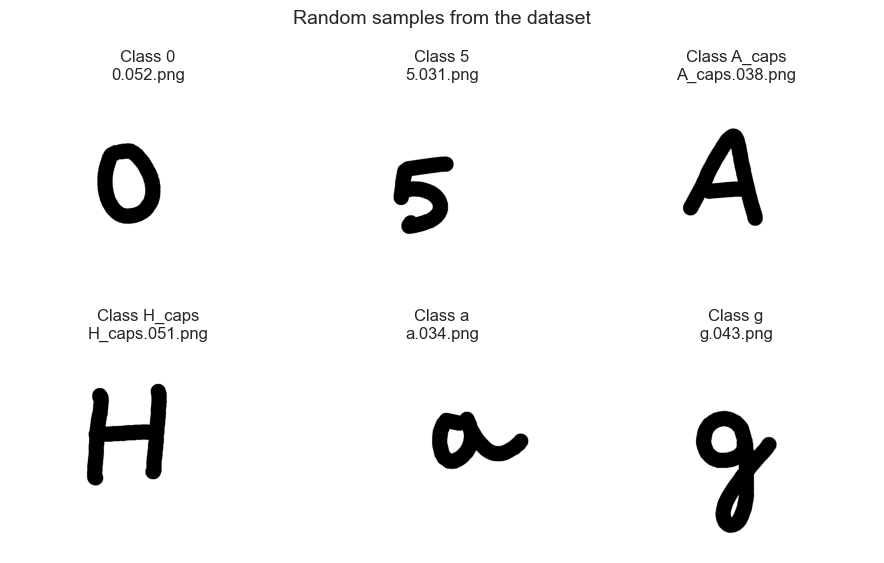

In [3]:
preview_classes = ["0", "5", "A_caps", "H_caps", "a", "g"]
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, cls in zip(axes.flat, preview_classes):
    files = CLASS_INDEX[cls]
    path = files[RNG.integers(len(files))]
    with Image.open(path) as img:
        ax.imshow(img.convert("L"), cmap="gray")
    ax.set_title(f"Class {cls}\n{path.name}")
    ax.axis("off")
fig.suptitle("Random samples from the dataset", fontsize=14)
plt.tight_layout()
plt.show()

## Helper utilities and solver setup

In [19]:
def _centered_axis(n: int) -> np.ndarray:
    return (np.arange(n, dtype=np.float64) + 0.5) / n


def image_to_density_measure(path: Path):
    """Convert an image to a normalized 2D density on a centered [0,1]^2 grid."""
    with Image.open(path) as img:
        arr = np.asarray(img.convert("L").resize((GRID_RESOLUTION, GRID_RESOLUTION), Image.BILINEAR), dtype=np.float64)
    total = arr.sum()
    if total <= 0:
        arr = np.ones_like(arr) / arr.size
    else:
        arr = arr / total
    axis = _centered_axis(arr.shape[0])
    return GridMeasure(axes=[axis, axis], weights_nd=arr, name=str(path), normalize=False)


def build_problem(src_path: Path, tgt_path: Path, *, pair_label: str):
    """Return both grid and point-cloud views plus the full cost matrix."""
    mu_grid = image_to_density_measure(src_path)
    nu_grid = image_to_density_measure(tgt_path)

    mu_points, mu_weights = mu_grid.as_point_cloud(include_zeros=True)
    nu_points, nu_weights = nu_grid.as_point_cloud(include_zeros=True)
    mu_point_cloud = PointCloudMeasure(points=mu_points, weights=mu_weights, name=f"mu-{pair_label}")
    nu_point_cloud = PointCloudMeasure(points=nu_points, weights=nu_weights, name=f"nu-{pair_label}")
    cost = cost_euclid_squared(mu_points, nu_points)

    return {
        "pair_label": pair_label,
        "grid_marginals": (mu_grid, nu_grid),
        "point_cloud_marginals": (mu_point_cloud, nu_point_cloud),
        "cost": cost,
    }


def sample_pairs_within_class(class_name: str, n_pairs: int, rng: np.random.Generator):
    files = CLASS_INDEX[class_name]
    if len(files) < 2:
        raise ValueError(f"Class {class_name} does not have enough images to form pairs.")
    pairs = []
    for _ in range(n_pairs):
        idx = rng.integers(len(files), size=2)
        pairs.append((files[idx[0]], files[idx[1]], class_name, class_name))
    return pairs


def sample_pairs_between_classes(class_pool: list[str], n_pairs: int, rng: np.random.Generator):
    pool = [cls for cls in class_pool if cls in CLASS_INDEX]
    if len(pool) < 2:
        raise ValueError("Need at least two classes to sample between-class pairs.")
    pairs = []
    for _ in range(n_pairs):
        cls_src, cls_tgt = rng.choice(pool, size=2, replace=False)
        src_list = CLASS_INDEX[cls_src]
        tgt_list = CLASS_INDEX[cls_tgt]
        pairs.append(
            (
                src_list[rng.integers(len(src_list))],
                tgt_list[rng.integers(len(tgt_list))],
                cls_src,
                cls_tgt,
            )
        )
    return pairs


lp_solver = LinearProgrammingTwoMarginalSolver()
pdhg_solver = PDLPSolver()
sinkhorn_solver = SinkhornTwoMarginalSolver()
bfm_adaptive_solver = BackNForthSqEuclideanSolver(pushforward_fn="adaptive")
bfm_cic_solver = BackNForthSqEuclideanSolver(pushforward_fn="cic")

bfm_common_kwargs = dict(maxiter=500, tol=1e-3, stepsize=1.0, error_metric="h1_psi_relative")

SOLVER_CONFIGS = [
    {"name": "Linear Program", "solver": lp_solver, "kwargs": {}},
    {"name": "PDHG (reg=10)", "solver": pdhg_solver, "kwargs": {"reg": 10.0}},
    {"name": "Sinkhorn (eps=1e-2)", "solver": sinkhorn_solver, "kwargs": {"reg": 1e-2, "maxiter": 2000}},
    {"name": "Sinkhorn (eps=1e-3)", "solver": sinkhorn_solver, "kwargs": {"reg": 1e-3, "maxiter": 3000}},
    {"name": "Back-and-Forth (adaptive)", "solver": bfm_adaptive_solver, "kwargs": bfm_common_kwargs},
    {"name": "Back-and-Forth (cic)", "solver": bfm_cic_solver, "kwargs": bfm_common_kwargs},
]


def _block_until_ready(tree):
    def _block(x):
        if isinstance(x, jax.Array):
            x.block_until_ready()
        return x
    return jax.tree_util.tree_map(_block, tree)


def solve_with_profiling(problem_data, solver, solver_kwargs):
    if isinstance(solver, BackNForthSqEuclideanSolver):
        marginals = problem_data["grid_marginals"]
        costs = []
    else:
        marginals = problem_data["point_cloud_marginals"]
        costs = [problem_data["cost"]]

    def _call_solver():
        start = time.perf_counter()
        result = solver.solve(marginals=marginals, costs=costs, **solver_kwargs)
        _block_until_ready(result)
        runtime = time.perf_counter() - start
        return runtime, result

    peak_mem, (runtime_s, outputs) = memory_usage(
        (_call_solver, (), {}),
        retval=True,
        max_usage=True,
        include_children=True,
        interval=0.05,
    )
    if isinstance(peak_mem, (list, tuple)):
        peak_mem = peak_mem[0]

    cost_value = float(np.asarray(outputs["cost"]))

    return {
        "runtime_s": runtime_s,
        "transport_cost": cost_value,
        "peak_memory_mb": float(peak_mem),
    }


def benchmark_pair_list(pair_specs, tag: str):
    records = []
    for pair_idx, (src_path, tgt_path, src_cls, tgt_cls) in enumerate(pair_specs):
        problem_data = build_problem(src_path, tgt_path, pair_label=f"{tag}-{pair_idx:02d}")
        print(f"Benchmarking pair {pair_idx + 1}/{len(pair_specs)}: {src_path.name} -> {tgt_path.name}")
        for config in SOLVER_CONFIGS:
            metrics = solve_with_profiling(problem_data, config["solver"], config["kwargs"])
            metrics.update(
                {
                    "solver": config["name"],
                    "pair_group": tag,
                    "pair_idx": pair_idx,
                    "source_class": src_cls,
                    "target_class": tgt_cls,
                    "source_path": str(src_path),
                    "target_path": str(tgt_path),
                }
            )
            records.append(metrics)
    return pd.DataFrame.from_records(records)


def plot_metric_boxplots(df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    metrics = [
        ("runtime_s", "Runtime (s)"),
        ("transport_cost", "Transportation cost"),
        ("peak_memory_mb", "Peak memory (MB)"),
    ]
    for ax, (col, label) in zip(axes, metrics):
        sns.boxplot(data=df, x="solver", y=col, ax=ax)
        if col == "runtime_s" or col == "transport_cost":
            ax.set_yscale("log")
        ax.set_xlabel("")
        ax.set_ylabel(label)
        ax.tick_params(axis="x", rotation=40)
    fig.suptitle(title, fontsize=14)
    plt.show()


def visualize_sample_pairs(pair_specs, title: str, max_pairs: int = 3):
    sample = pair_specs[:max_pairs]
    if not sample:
        print("No pairs provided for visualization.")
        return
    fig, axes = plt.subplots(len(sample), 4, figsize=(14, 4 * len(sample)), constrained_layout=True)
    if len(sample) == 1:
        axes = axes[None, :]
    for row, (src_path, tgt_path, src_cls, tgt_cls) in enumerate(sample):
        with Image.open(src_path) as img:
            src_img = np.asarray(img.convert("L").resize((GRID_RESOLUTION, GRID_RESOLUTION), Image.BILINEAR))
        with Image.open(tgt_path) as img:
            tgt_img = np.asarray(img.convert("L").resize((GRID_RESOLUTION, GRID_RESOLUTION), Image.BILINEAR))
        problem_data = build_problem(src_path, tgt_path, pair_label=f"preview-{row}")
        mu_grid, nu_grid = problem_data["grid_marginals"]
        axes[row, 0].imshow(src_img, cmap="gray")
        axes[row, 0].set_title(f"Source image ({src_cls})")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(np.asarray(mu_grid.weights_nd), cmap="magma")
        axes[row, 1].set_title("Source density")
        axes[row, 1].axis("off")
        axes[row, 2].imshow(tgt_img, cmap="gray")
        axes[row, 2].set_title(f"Target image ({tgt_cls})")
        axes[row, 2].axis("off")
        axes[row, 3].imshow(np.asarray(nu_grid.weights_nd), cmap="magma")
        axes[row, 3].set_title("Target density")
        axes[row, 3].axis("off")
    fig.suptitle(title, fontsize=14)
    plt.show()


## Problem size diagnostics
To understand the dimensionality of each OT instance we inspect one sampled pair, reporting the density grid shape, number of point-cloud support points (including zero-weight bins), and the resulting cost matrix dimensions.

In [5]:
example_src = CLASS_INDEX[IN_CLASS_NAME][0]
example_tgt = CLASS_INDEX[IN_CLASS_NAME][1 if len(CLASS_INDEX[IN_CLASS_NAME]) > 1 else 0]
example_problem = build_problem(example_src, example_tgt, pair_label="diagnostic")
mu_grid, nu_grid = example_problem["grid_marginals"]
mu_point_cloud, nu_point_cloud = example_problem["point_cloud_marginals"]
mu_points, mu_weights = mu_point_cloud.as_point_cloud(include_zeros=True)
nu_points, nu_weights = nu_point_cloud.as_point_cloud(include_zeros=True)

print("Grid axes lengths:", [len(ax) for ax in mu_grid.axes])
print("Grid weight shape (mu):", mu_grid.weights_nd.shape)
print("Number of point-cloud support points:", mu_points.shape[0])
print("Cost matrix shape:", example_problem["cost"].shape)
print("Total mass mu/nu:", mu_weights.sum(), nu_weights.sum())

Grid axes lengths: [64, 64]
Grid weight shape (mu): (64, 64)
Number of discrete support points: 4096
Cost matrix shape: (4096, 4096)
Total mass mu/nu: 0.9999999999999999 1.0000000000000002


### In-class discretized samples
We visualize a few A_caps pairs after converting them to normalized density grids to ensure the discretization looks reasonable.

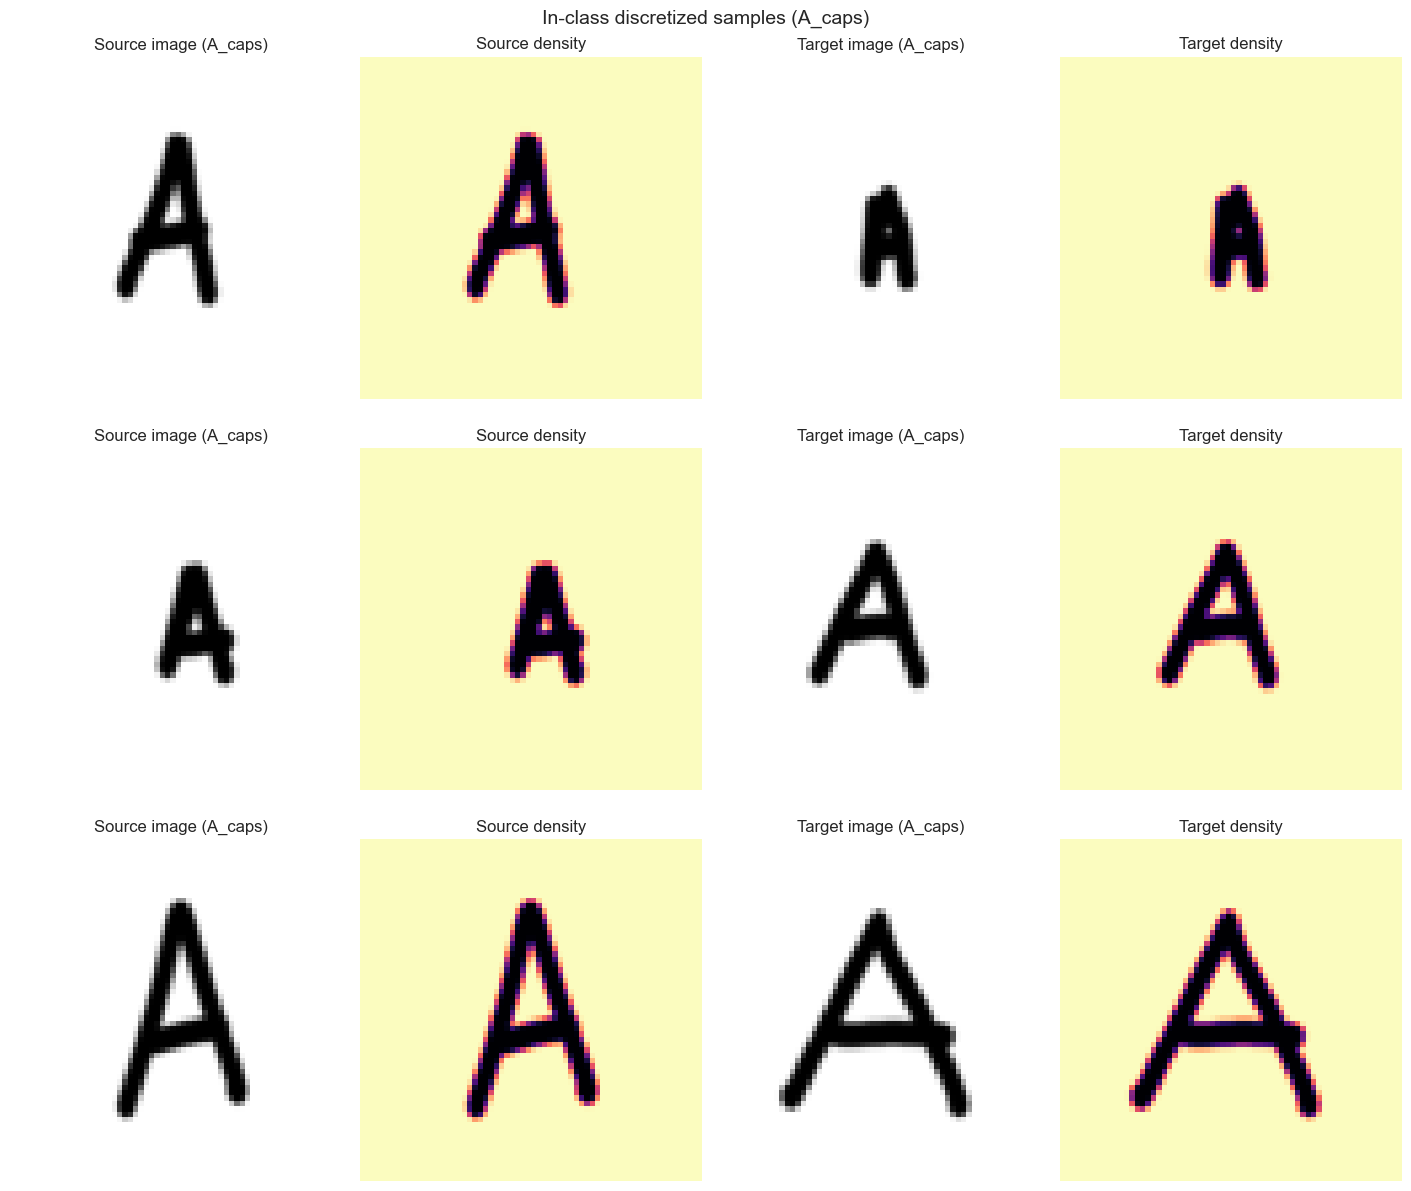

In [6]:
preview_rng_in = np.random.default_rng(SEED + 12345)
preview_pairs_in_class = sample_pairs_within_class(IN_CLASS_NAME, 3, preview_rng_in)
visualize_sample_pairs(preview_pairs_in_class, title=f"In-class discretized samples ({IN_CLASS_NAME})")


### Between-class discretized samples
We also inspect a few randomly drawn source/target pairs coming from different classes.

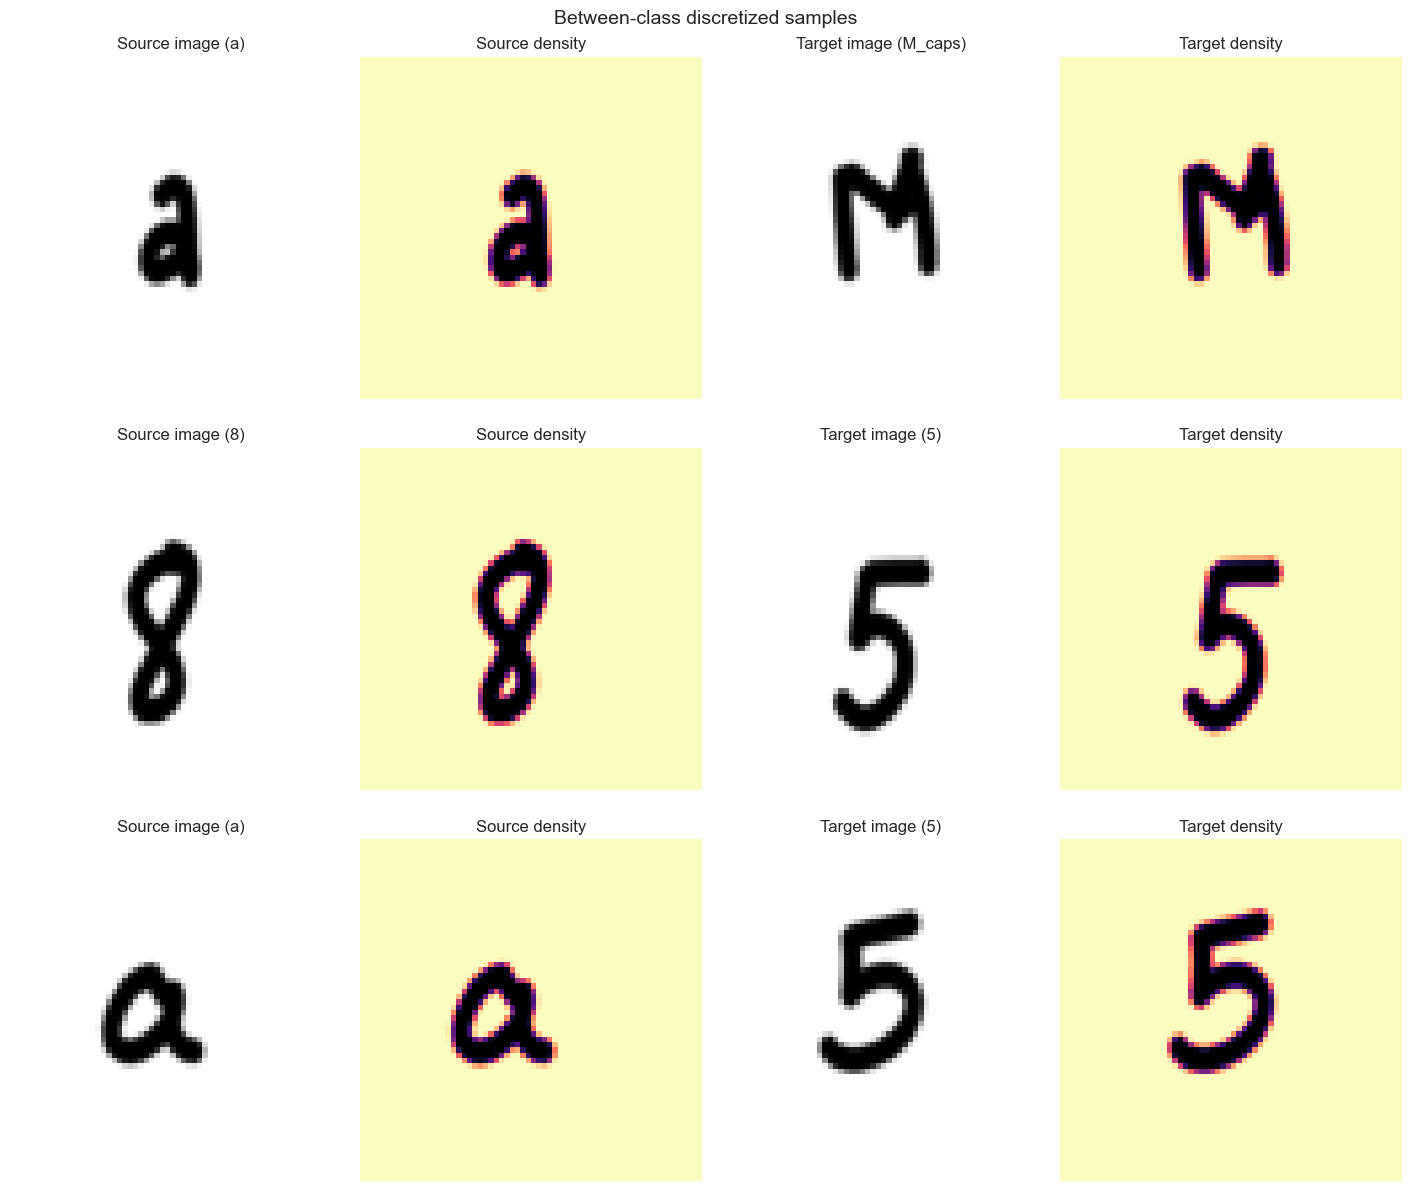

In [7]:
preview_rng_between = np.random.default_rng(SEED + 23456)
preview_pairs_between = sample_pairs_between_classes(BETWEEN_CLASS_POOL, 3, preview_rng_between)
visualize_sample_pairs(preview_pairs_between, title="Between-class discretized samples")


## In-class benchmark

We first benchmark solvers on pairs drawn from the same class. Here we sample 30 random source/target combinations from the `A_caps` folder (replacement allowed), convert each pair into an OT problem, and measure runtime, cost, and peak memory.

In [8]:
in_class_pairs = sample_pairs_within_class(IN_CLASS_NAME, N_IN_CLASS_PAIRS, RNG)
len(in_class_pairs)

30

In [9]:
in_class_metrics = benchmark_pair_list(in_class_pairs, tag=f"in-class-{IN_CLASS_NAME}")
in_class_metrics.head()

Benchmarking pair 1/30: A_caps.046.png -> A_caps.013.png
Benchmarking pair 2/30: A_caps.003.png -> A_caps.017.png
Benchmarking pair 3/30: A_caps.016.png -> A_caps.048.png
Benchmarking pair 4/30: A_caps.052.png -> A_caps.001.png
Benchmarking pair 5/30: A_caps.026.png -> A_caps.046.png
Benchmarking pair 6/30: A_caps.007.png -> A_caps.045.png
Benchmarking pair 7/30: A_caps.007.png -> A_caps.025.png
Benchmarking pair 8/30: A_caps.045.png -> A_caps.017.png
Benchmarking pair 9/30: A_caps.019.png -> A_caps.016.png
Benchmarking pair 10/30: A_caps.040.png -> A_caps.015.png
Benchmarking pair 11/30: A_caps.055.png -> A_caps.023.png
Benchmarking pair 12/30: A_caps.026.png -> A_caps.027.png
Benchmarking pair 13/30: A_caps.032.png -> A_caps.031.png
Benchmarking pair 14/30: A_caps.027.png -> A_caps.055.png
Benchmarking pair 15/30: A_caps.045.png -> A_caps.043.png
Benchmarking pair 16/30: A_caps.038.png -> A_caps.035.png
Benchmarking pair 17/30: A_caps.019.png -> A_caps.055.png
Benchmarking pair 18/30

/Users/ivanzhytkevych/Desktop/ot-algorithm-comparison/.venv/lib/python3.13/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Benchmarking pair 20/30: A_caps.047.png -> A_caps.033.png
Benchmarking pair 21/30: A_caps.007.png -> A_caps.002.png
Benchmarking pair 22/30: A_caps.023.png -> A_caps.002.png
Benchmarking pair 23/30: A_caps.008.png -> A_caps.027.png
Benchmarking pair 24/30: A_caps.054.png -> A_caps.025.png
Benchmarking pair 25/30: A_caps.045.png -> A_caps.052.png
Benchmarking pair 26/30: A_caps.046.png -> A_caps.035.png
Benchmarking pair 27/30: A_caps.023.png -> A_caps.027.png
Benchmarking pair 28/30: A_caps.015.png -> A_caps.026.png
Benchmarking pair 29/30: A_caps.020.png -> A_caps.014.png
Benchmarking pair 30/30: A_caps.055.png -> A_caps.001.png


,runtime_s,transport_cost,peak_memory_mb,solver,pair_group,pair_idx,source_class,target_class,source_path,target_path
0,1.068814,0.000393,1471.890625,Linear Program,in-class-A_caps,0,A_caps,A_caps,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
1,27.235402,0.000544,3748.687500,PDHG (reg=10),in-class-A_caps,0,A_caps,A_caps,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
2,3.552038,0.009551,1836.859375,Sinkhorn (eps=1e-2),in-class-A_caps,0,A_caps,A_caps,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
3,32.655523,0.001304,1838.359375,Sinkhorn (eps=1e-3),in-class-A_caps,0,A_caps,A_caps,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
4,2.406420,0.000317,1714.250000,Back-and-Forth (adaptive),in-class-A_caps,0,A_caps,A_caps,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...


In [10]:
in_class_summary = in_class_metrics.groupby("solver")[ ["runtime_s", "transport_cost", "peak_memory_mb"] ].describe().round(4)
in_class_summary

runtime_s                                     \
                              count     mean     std      min      25%   
solver                                                                   
Back-and-Forth (adaptive)      30.0   0.3231  0.3935   0.2417   0.2476   
Back-and-Forth (cic)           30.0   0.0607  0.1341   0.0077   0.0374   
Linear Program                 30.0   1.3179  1.0415   0.8171   0.9526   
PDHG (reg=10)                  30.0  25.6335  4.2915  15.6199  23.1638   
Sinkhorn (eps=1e-2)            30.0   3.3065  0.4259   1.9774   3.2274   
Sinkhorn (eps=1e-3)            30.0  31.4623  4.1319  20.2558  30.1801   

                                                     transport_cost          \
                               50%      75%      max          count    mean   
solver                                                                        
Back-and-Forth (adaptive)   0.2499   0.2553   2.4064           30.0  0.0002   
Back-and-Forth (cic)        0.0381   0.0390   0.7696           30.0  0.0004   
Linear Program              1.0426   1.2272   6.5818           30.0  0.0003   
PDHG (reg=10)              25.2135  29.6276  31.3047           30.0  0.0005   
Sinkhorn (eps=1e-2)         3.2733   3.5204   3.9917           30.0  0.0094   
Sinkhorn (eps=1e-3)        31.5331  34.0859  38.1787           30.0  0.0012   

                           ...                 peak_memory_mb             \
                           ...     75%     max          count       mean   
solver                     ...                                             
Back-and-Forth (adaptive)  ...  0.0003  0.0011           30.0  1884.0859   
Back-and-Forth (cic)       ...  0.0004  0.0012           30.0  1881.7469   
Linear Program             ...  0.0004  0.0013           30.0  1868.2354   
PDHG (reg=10)              ...  0.0005  0.0014           30.0  4051.9854   
Sinkhorn (eps=1e-2)        ...  0.0095  0.0103           30.0  2137.0474   
Sinkhorn (eps=1e-3)        ...  0.0013  0.0022           30.0  2138.3656   

                                                                      \
                                std        min        25%        50%   
solver                                                                 
Back-and-Forth (adaptive)   85.1925  1714.2500  1815.1328  1882.0469   
Back-and-Forth (cic)        79.2296  1763.9688  1815.0781  1872.4297   
Linear Program             108.1066  1471.8906  1807.6523  1873.2812   
PDHG (reg=10)               96.9815  3748.6875  3988.0078  4055.0078   
Sinkhorn (eps=1e-2)         96.5610  1836.8594  2072.9844  2138.7969   
Sinkhorn (eps=1e-3)         96.5419  1838.3594  2073.5352  2141.3750   

                                                 
                                 75%        max  
solver                                           
Back-and-Forth (adaptive)  1950.9414  2022.7188  
Back-and-Forth (cic)       1951.1641  2017.6562  
Linear Program             1943.3242  2019.0469  
PDHG (reg=10)              4124.1680  4199.0156  
Sinkhorn (eps=1e-2)        2208.8359  2284.5625  
Sinkhorn (eps=1e-3)        2210.4844  2284.3594  

[6 rows x 24 columns]

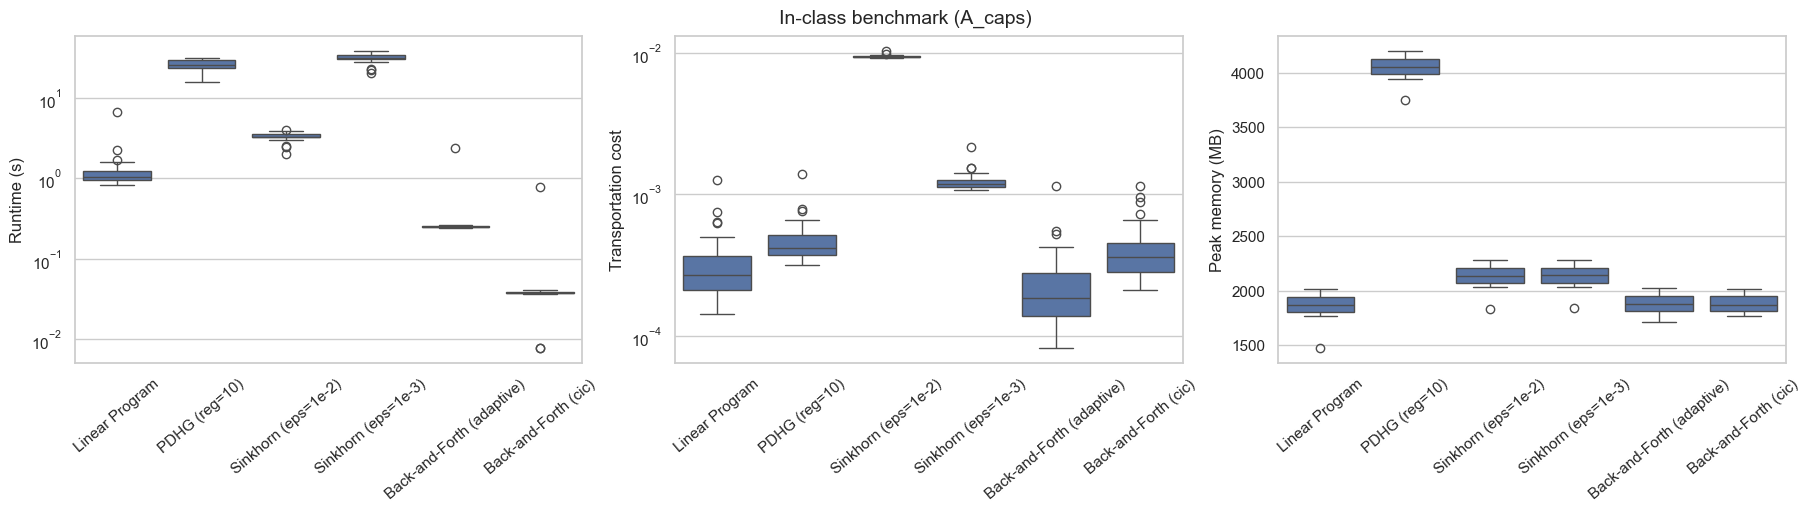

In [20]:
plot_metric_boxplots(in_class_metrics, title=f"In-class benchmark ({IN_CLASS_NAME})")

## Between-class benchmark

Next we compare solvers on 30 pairs where source and target images always come from different classes selected from a mixed pool of digits (0/3/5/8), uppercase letters (A/M/S), and lowercase letters (a/g/m).

In [12]:
between_class_pairs = sample_pairs_between_classes(BETWEEN_CLASS_POOL, N_BETWEEN_CLASS_PAIRS, RNG)
len(between_class_pairs)

30

In [13]:
between_class_metrics = benchmark_pair_list(between_class_pairs, tag="between-classes")
between_class_metrics.head()

Benchmarking pair 1/30: 0.039.png -> 3.050.png
Benchmarking pair 2/30: a.030.png -> 3.001.png
Benchmarking pair 3/30: M_caps.009.png -> g.029.png
Benchmarking pair 4/30: 5.010.png -> m.029.png
Benchmarking pair 5/30: g.034.png -> m.003.png
Benchmarking pair 6/30: A_caps.014.png -> S_caps.029.png
Benchmarking pair 7/30: S_caps.049.png -> M_caps.039.png
Benchmarking pair 8/30: 8.006.png -> S_caps.004.png
Benchmarking pair 9/30: M_caps.019.png -> 8.012.png
Benchmarking pair 10/30: 3.026.png -> 8.019.png
Benchmarking pair 11/30: m.033.png -> M_caps.024.png
Benchmarking pair 12/30: M_caps.032.png -> A_caps.037.png
Benchmarking pair 13/30: g.024.png -> 3.024.png
Benchmarking pair 14/30: 0.047.png -> 5.006.png
Benchmarking pair 15/30: 8.012.png -> m.001.png
Benchmarking pair 16/30: 0.028.png -> S_caps.049.png
Benchmarking pair 17/30: 0.008.png -> S_caps.048.png
Benchmarking pair 18/30: a.035.png -> A_caps.050.png
Benchmarking pair 19/30: M_caps.009.png -> g.030.png
Benchmarking pair 20/30: 3.

,runtime_s,transport_cost,peak_memory_mb,solver,pair_group,pair_idx,source_class,target_class,source_path,target_path
0,0.980284,0.000458,2030.328125,Linear Program,between-classes,0,0,3,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
1,28.946865,0.000602,4211.500000,PDHG (reg=10),between-classes,0,0,3,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
2,3.271188,0.009592,2296.765625,Sinkhorn (eps=1e-2),between-classes,0,0,3,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
3,30.921141,0.001360,2297.531250,Sinkhorn (eps=1e-3),between-classes,0,0,3,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...
4,0.248143,0.000364,2039.578125,Back-and-Forth (adaptive),between-classes,0,0,3,../eng_char_and_digits_mann/handwritten-englis...,../eng_char_and_digits_mann/handwritten-englis...


In [14]:
between_class_summary = between_class_metrics.groupby("solver")[ ["runtime_s", "transport_cost", "peak_memory_mb"] ].describe().round(4)
between_class_summary

runtime_s                                     \
                              count     mean     std      min      25%   
solver                                                                   
Back-and-Forth (adaptive)      30.0   0.2591  0.0179   0.2475   0.2502   
Back-and-Forth (cic)           30.0   0.0389  0.0011   0.0373   0.0381   
Linear Program                 30.0   1.2424  0.6255   0.8417   1.0073   
PDHG (reg=10)                  30.0  27.3422  3.8478  18.0082  24.4034   
Sinkhorn (eps=1e-2)            30.0   3.4181  0.5741   1.5615   3.2297   
Sinkhorn (eps=1e-3)            30.0  32.8060  5.7645  14.6509  31.1967   

                                                     transport_cost          \
                               50%      75%      max          count    mean   
solver                                                                        
Back-and-Forth (adaptive)   0.2527   0.2656   0.3446           30.0  0.0005   
Back-and-Forth (cic)        0.0387   0.0398   0.0420           30.0  0.0006   
Linear Program              1.1202   1.2779   4.3848           30.0  0.0006   
PDHG (reg=10)              28.1560  31.1374  31.6446           30.0  0.0007   
Sinkhorn (eps=1e-2)         3.5376   3.7303   4.2635           30.0  0.0097   
Sinkhorn (eps=1e-3)        33.9740  36.4833  40.7826           30.0  0.0015   

                           ...                 peak_memory_mb             \
                           ...     75%     max          count       mean   
solver                     ...                                             
Back-and-Forth (adaptive)  ...  0.0005  0.0025           30.0  2202.8255   
Back-and-Forth (cic)       ...  0.0008  0.0026           30.0  2202.0828   
Linear Program             ...  0.0006  0.0026           30.0  2193.7078   
PDHG (reg=10)              ...  0.0008  0.0027           30.0  4374.3427   
Sinkhorn (eps=1e-2)        ...  0.0097  0.0116           30.0  2459.3682   
Sinkhorn (eps=1e-3)        ...  0.0015  0.0035           30.0  2460.3406   

                                                                      \
                                std        min        25%        50%   
solver                                                                 
Back-and-Forth (adaptive)  120.9974  2039.5781  2113.6094  2187.2656   
Back-and-Forth (cic)       120.7875  2038.5312  2112.3984  2186.8906   
Linear Program             120.6256  2030.3281  2107.7031  2179.9922   
PDHG (reg=10)              120.8977  4211.5000  4287.5430  4361.6562   
Sinkhorn (eps=1e-2)        120.9569  2296.7656  2372.5625  2445.2969   
Sinkhorn (eps=1e-3)        120.9131  2297.5312  2373.0508  2445.6328   

                                                 
                                 75%        max  
solver                                           
Back-and-Forth (adaptive)  2255.9297  2465.5938  
Back-and-Forth (cic)       2254.6992  2465.3750  
Linear Program             2245.8203  2458.4219  
PDHG (reg=10)              4426.8477  4638.7969  
Sinkhorn (eps=1e-2)        2511.6680  2724.1875  
Sinkhorn (eps=1e-3)        2513.2656  2724.4062  

[6 rows x 24 columns]

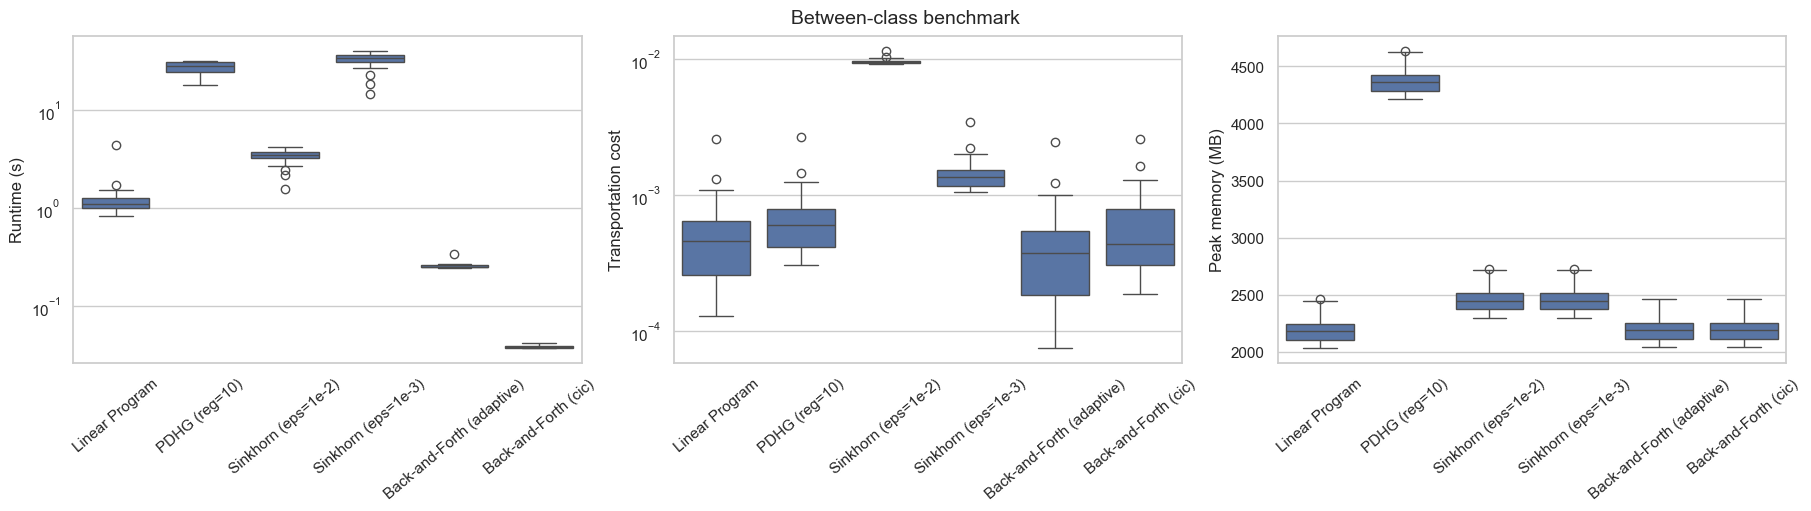

In [21]:
plot_metric_boxplots(between_class_metrics, title="Between-class benchmark")